In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# グラフのスタイル設定
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_palette("husl")

## データの読み込みと集計

In [12]:
# 実験の設定
datasets = ['BH', 'SM', 'NiB']
models = ['bayes_10rounds_10trials',
          'gnn_bo_100trials_conv1','gnn_bo_100trials_conv2', 'gnn_bo_100trials_conv3',
          'gpr_100trials', 'optuna_tpe_100trials']
model_labels = ['ReactionT5 BO', 'GNN BO Conv1', 'GNN BO Conv2', 'GNN BO Conv3', 'GPR BO', 'Optuna TPE']
seeds = [1, 2, 3, 4, 5]
runs_dir = Path('../runs')

print(f"データセット: {datasets}")
print(f"モデル: {model_labels}")
print(f"シード: {seeds}")

データセット: ['BH', 'SM', 'NiB']
モデル: ['ReactionT5 BO', 'GNN BO Conv1', 'GNN BO Conv2', 'GNN BO Conv3', 'GPR BO', 'Optuna TPE']
シード: [1, 2, 3, 4, 5]


In [13]:
import sqlite3

def load_optimization_log(model, dataset, seed):
    """
    最適化ログを読み込む
    
    Args:
        model: モデル名
        dataset: データセット名
        seed: シード番号
    
    Returns:
        DataFrame: 最適化ログ
    """
    run_name = f"{model}_{dataset}_seed{seed}"
    
    # optuna_tpeの場合はDBから読み込み
    if 'optuna_tpe' in model:
        db_path = runs_dir / run_name / f"{run_name}.db"
        if not db_path.exists():
            print(f"Warning: {db_path} not found")
            return None
        
        try:
            conn = sqlite3.connect(str(db_path))
            # trial number と value (yield) を取得
            query = """
            SELECT t.number as trial, tv.value as actual_yield
            FROM trials t
            JOIN trial_values tv ON t.trial_id = tv.trial_id
            ORDER BY t.number
            """
            df = pd.read_sql_query(query, conn)
            conn.close()
            
            # trial番号を1始まりに調整
            df['trial'] = df['trial'] + 1
            df['model'] = model
            df['dataset'] = dataset
            df['seed'] = seed
            return df
        except Exception as e:
            print(f"Error loading {db_path}: {e}")
            return None
    else:
        # ReactionT5, gprの場合はCSVから読み込み
        log_path = runs_dir / run_name / "optimization_log.csv"
        
        if not log_path.exists():
            print(f"Warning: {log_path} not found")
            return None
        
        try:
            df = pd.read_csv(log_path)
            
            df['model'] = model
            df['dataset'] = dataset
            df['seed'] = seed
            return df
        except Exception as e:
            print(f"Error loading {log_path}: {e}")
            return None

# 全データを読み込み
all_logs = []

for dataset in datasets:
    for model in models:
        for seed in seeds:
            df = load_optimization_log(model, dataset, seed)
            if df is not None:
                all_logs.append(df)

# 全データを結合
if all_logs:
    combined_df = pd.concat(all_logs, ignore_index=True)
    print(f"\n読み込み完了: {len(all_logs)} ファイル, 合計 {len(combined_df)} レコード")
    print("\nデータセット別カウント:")
    print(combined_df.groupby(['dataset', 'model', 'seed']).size().unstack(fill_value=0))
else:
    print("データが読み込めませんでした")


読み込み完了: 90 ファイル, 合計 9000 レコード

データセット別カウント:
seed                               1    2    3    4    5
dataset model                                           
BH      bayes_10rounds_10trials  100  100  100  100  100
        gnn_bo_100trials_conv1   100  100  100  100  100
        gnn_bo_100trials_conv2   100  100  100  100  100
        gnn_bo_100trials_conv3   100  100  100  100  100
        gpr_100trials            100  100  100  100  100
        optuna_tpe_100trials     100  100  100  100  100
NiB     bayes_10rounds_10trials  100  100  100  100  100
        gnn_bo_100trials_conv1   100  100  100  100  100
        gnn_bo_100trials_conv2   100  100  100  100  100
        gnn_bo_100trials_conv3   100  100  100  100  100
        gpr_100trials            100  100  100  100  100
        optuna_tpe_100trials     100  100  100  100  100
SM      bayes_10rounds_10trials  100  100  100  100  100
        gnn_bo_100trials_conv1   100  100  100  100  100
        gnn_bo_100trials_conv2   100  100  

In [14]:
# 各モデル・データセット・シードごとの統計を計算
stats_list = []

for dataset in datasets:
    for model in models:
        for seed in seeds:
            df_subset = combined_df[
                (combined_df['dataset'] == dataset) & 
                (combined_df['model'] == model) & 
                (combined_df['seed'] == seed)
            ].copy()
            
            if len(df_subset) > 0:
                # trialでソート
                if 'trial' in df_subset.columns:
                    df_subset = df_subset.sort_values('trial')
                
                # 累積最大収率を計算
                cumulative_max = df_subset['actual_yield'].cummax()
                
                stats = {
                    'dataset': dataset,
                    'model': model,
                    'seed': seed,
                    'max_yield': df_subset['actual_yield'].max(),
                    'mean_yield': df_subset['actual_yield'].mean(),
                    'final_best_yield': cumulative_max.iloc[-1],
                    'n_trials': len(df_subset),
                    'mae': np.abs(df_subset['error_pct']).mean() if 'error_pct' in df_subset.columns else np.nan
                }
                stats_list.append(stats)

stats_df = pd.DataFrame(stats_list)
print(f"対象モデル: {models}")
print("統計量の計算完了")
print("\n各モデルの試行数:")
print(stats_df.groupby(['dataset', 'model'])['n_trials'].first().unstack(fill_value=0))
print("\n")
stats_df.head(10)

対象モデル: ['bayes_10rounds_10trials', 'gnn_bo_100trials_conv1', 'gnn_bo_100trials_conv2', 'gnn_bo_100trials_conv3', 'gpr_100trials', 'optuna_tpe_100trials']
統計量の計算完了

各モデルの試行数:
model    bayes_10rounds_10trials  gnn_bo_100trials_conv1  \
dataset                                                    
BH                           100                     100   
NiB                          100                     100   
SM                           100                     100   

model    gnn_bo_100trials_conv2  gnn_bo_100trials_conv3  gpr_100trials  \
dataset                                                                  
BH                          100                     100            100   
NiB                         100                     100            100   
SM                          100                     100            100   

model    optuna_tpe_100trials  
dataset                        
BH                        100  
NiB                       100  
SM                        

,dataset,model,seed,max_yield,mean_yield,final_best_yield,n_trials,mae
0,BH,bayes_10rounds_10trials,1,99.034462,56.153066,99.034462,100,21.560342
1,BH,bayes_10rounds_10trials,2,99.034462,57.563522,99.034462,100,20.391465
2,BH,bayes_10rounds_10trials,3,99.034462,59.440374,99.034462,100,19.545583
3,BH,bayes_10rounds_10trials,4,99.034462,56.197114,99.034462,100,20.623277
4,BH,bayes_10rounds_10trials,5,96.132283,58.317902,96.132283,100,20.149746
5,BH,gnn_bo_100trials_conv1,1,92.391200,29.091636,92.391200,100,25.319994
6,BH,gnn_bo_100trials_conv1,2,94.296900,36.720049,94.296900,100,24.850480
7,BH,gnn_bo_100trials_conv1,3,95.129000,34.144594,95.129000,100,30.137582
8,BH,gnn_bo_100trials_conv1,4,95.070200,33.589355,95.070200,100,27.976012
9,BH,gnn_bo_100trials_conv1,5,95.752600,40.704411,95.752600,100,25.837347


## Optimization Progress Comparison

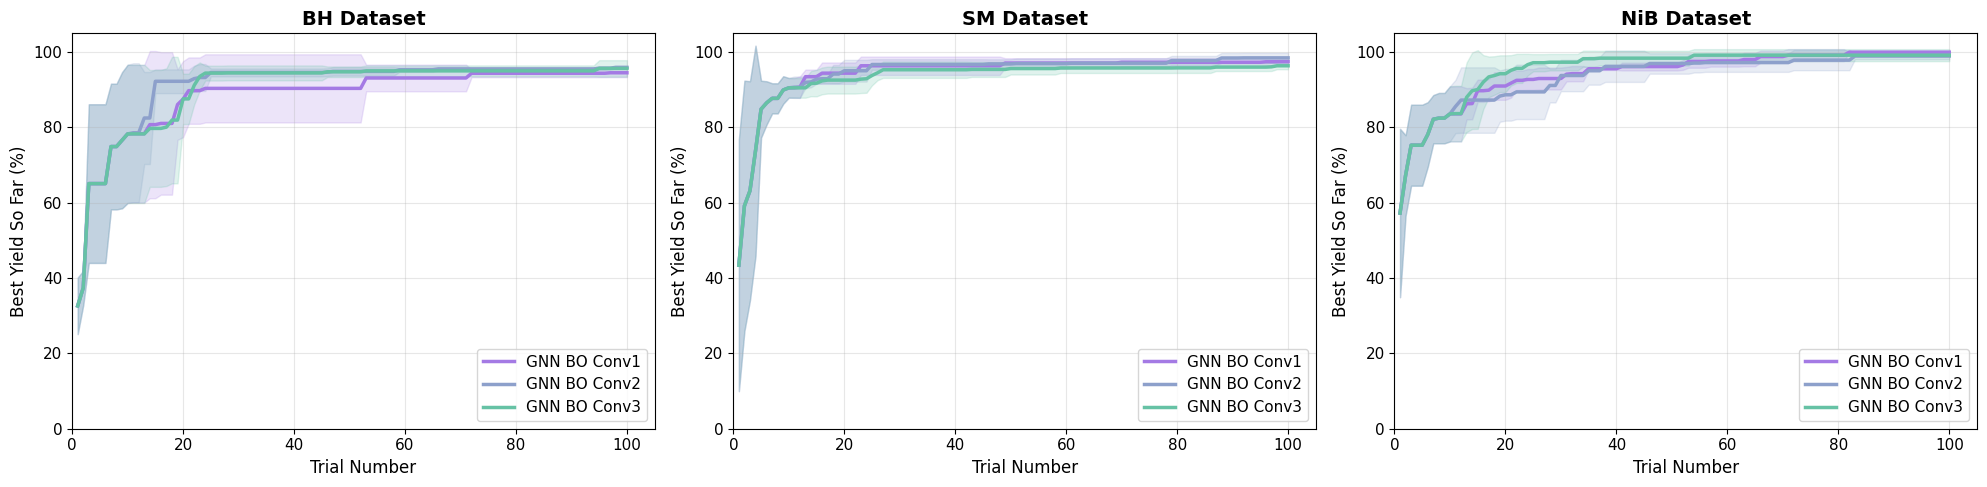

Optimization Progress比較プロット完了


In [15]:
target_models_gnn = [m for m in models if 'gnn' in m]
target_labels_gnn = [model_labels[i] for i, m in enumerate(models) if 'gnn' in m]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors =  ["#a47ae4", "#8da0cb", "#66c2a5"]

for i, dataset in enumerate(datasets):
    ax = axes[i]
    
    for j, (model, model_label) in enumerate(zip(target_models_gnn, target_labels_gnn)):  # Only include the GNN models
        # 各seedの進捗データを集める
        all_progress = []
        
        for seed in seeds:
            df_subset = combined_df[
                (combined_df['dataset'] == dataset) & 
                (combined_df['model'] == model) & 
                (combined_df['seed'] == seed)
            ].copy()
            
            if len(df_subset) > 0:
                # trialでソート
                if 'trial' in df_subset.columns:
                    df_subset = df_subset.sort_values('trial')
                
                # 累積最大値を計算（それまでに得られた最大収率）
                cumulative_max = df_subset['actual_yield'].cummax().values
                all_progress.append(cumulative_max)
        
        if all_progress:
            # 全seedの長さを確認して揃える
            lengths = [len(p) for p in all_progress]
            if len(set(lengths)) > 1:
                print(f"Info: {dataset} {model_label} lengths: {set(lengths)} - using minimum")
                min_len = min(lengths)
                all_progress = [p[:min_len] for p in all_progress]
            
            # 全seedの平均と標準偏差を計算
            all_progress = np.array(all_progress)
            mean_progress = np.mean(all_progress, axis=0)
            std_progress = np.std(all_progress, axis=0)
            trials = np.arange(1, len(mean_progress) + 1)
            
            # プロット: 平均を線で、標準偏差を塗りつぶしで
            ax.plot(trials, mean_progress, label=f'{model_label}', 
                   linewidth=2.5, color=colors[j])
            ax.fill_between(trials, 
                           mean_progress - std_progress,
                           mean_progress + std_progress,
                           alpha=0.2, color=colors[j])
    
    ax.set_title(f'{dataset} Dataset', fontsize=14, fontweight='bold')
    ax.set_xlabel('Trial Number', fontsize=12)
    ax.set_ylabel('Best Yield So Far (%)', fontsize=12)
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 105])
    ax.set_xlim([0, 105])

plt.tight_layout()
plt.show()

print("Optimization Progress比較プロット完了")

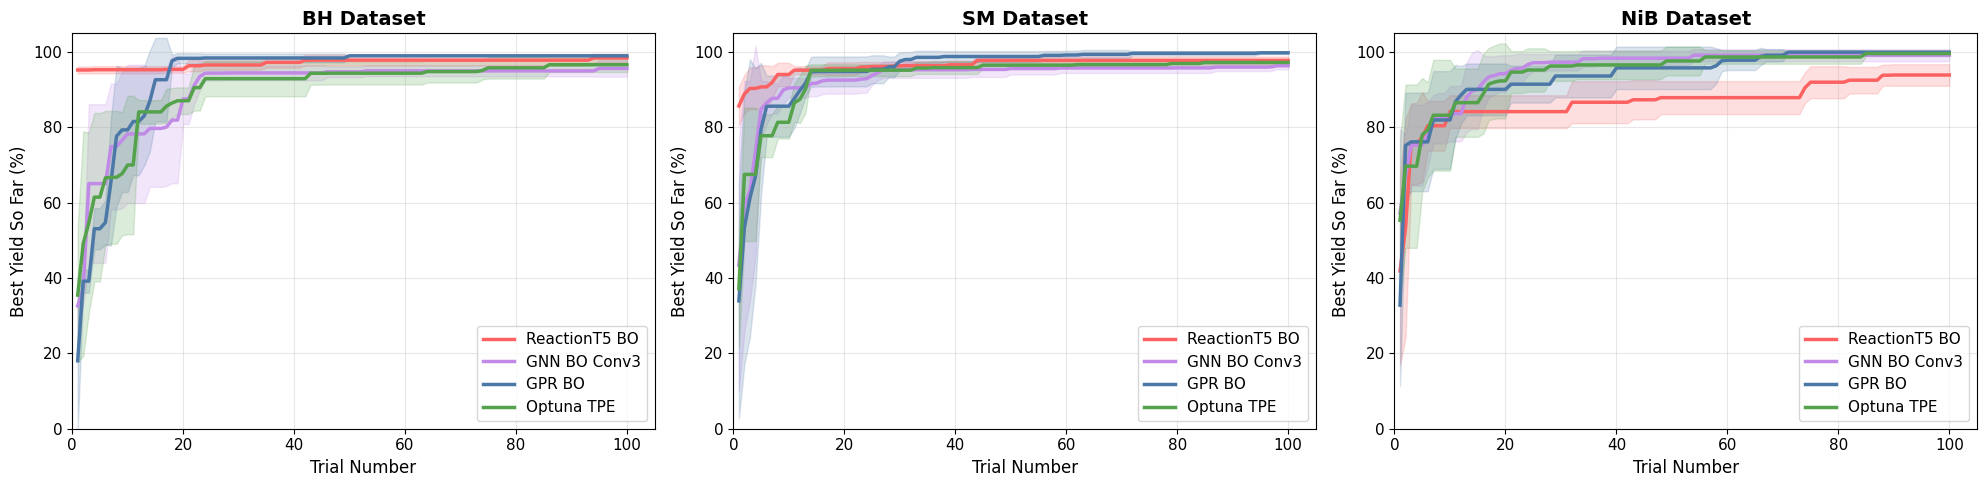

Optimization Progress比較プロット完了


In [16]:
target_models = [m for m in models if 'bayes' in m  or 'gnn_bo_100trials_conv3' in m or 'gpr' in m or 'optuna' in m]
target_labels = [model_labels[i] for i, m in enumerate(models) if 'bayes' in m  or 'gnn_bo_100trials_conv3' in m or 'gpr' in m or 'optuna' in m]
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors = ["#fc6262", "#c28ae7", "#4c78a8", "#54a24b"]

for i, dataset in enumerate(datasets):
    ax = axes[i]
    
    for j, (model, model_label) in enumerate(zip(target_models, target_labels)):  # Only include ReactionT5 BO, GPR BO, Optuna TPE
        # 各seedの進捗データを集める
        all_progress = []
        
        for seed in seeds:
            df_subset = combined_df[
                (combined_df['dataset'] == dataset) & 
                (combined_df['model'] == model) & 
                (combined_df['seed'] == seed)
            ].copy()
            
            if len(df_subset) > 0:
                # trialでソート
                if 'trial' in df_subset.columns:
                    df_subset = df_subset.sort_values('trial')
                
                # 累積最大値を計算（それまでに得られた最大収率）
                cumulative_max = df_subset['actual_yield'].cummax().values
                all_progress.append(cumulative_max)
        
        if all_progress:
            # 全seedの長さを確認して揃える
            lengths = [len(p) for p in all_progress]
            if len(set(lengths)) > 1:
                print(f"Info: {dataset} {model_label} lengths: {set(lengths)} - using minimum")
                min_len = min(lengths)
                all_progress = [p[:min_len] for p in all_progress]
            
            # 全seedの平均と標準偏差を計算
            all_progress = np.array(all_progress)
            mean_progress = np.mean(all_progress, axis=0)
            std_progress = np.std(all_progress, axis=0)
            trials = np.arange(1, len(mean_progress) + 1)
            
            # プロット: 平均を線で、標準偏差を塗りつぶしで
            ax.plot(trials, mean_progress, label=f'{model_label}', 
                   linewidth=2.5, color=colors[j])
            ax.fill_between(trials, 
                           mean_progress - std_progress,
                           mean_progress + std_progress,
                           alpha=0.2, color=colors[j])
    
    ax.set_title(f'{dataset} Dataset', fontsize=14, fontweight='bold')
    ax.set_xlabel('Trial Number', fontsize=12)
    ax.set_ylabel('Best Yield So Far (%)', fontsize=12)
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 105])
    ax.set_xlim([0, 105])

plt.tight_layout()
plt.show()

print("Optimization Progress比較プロット完了")

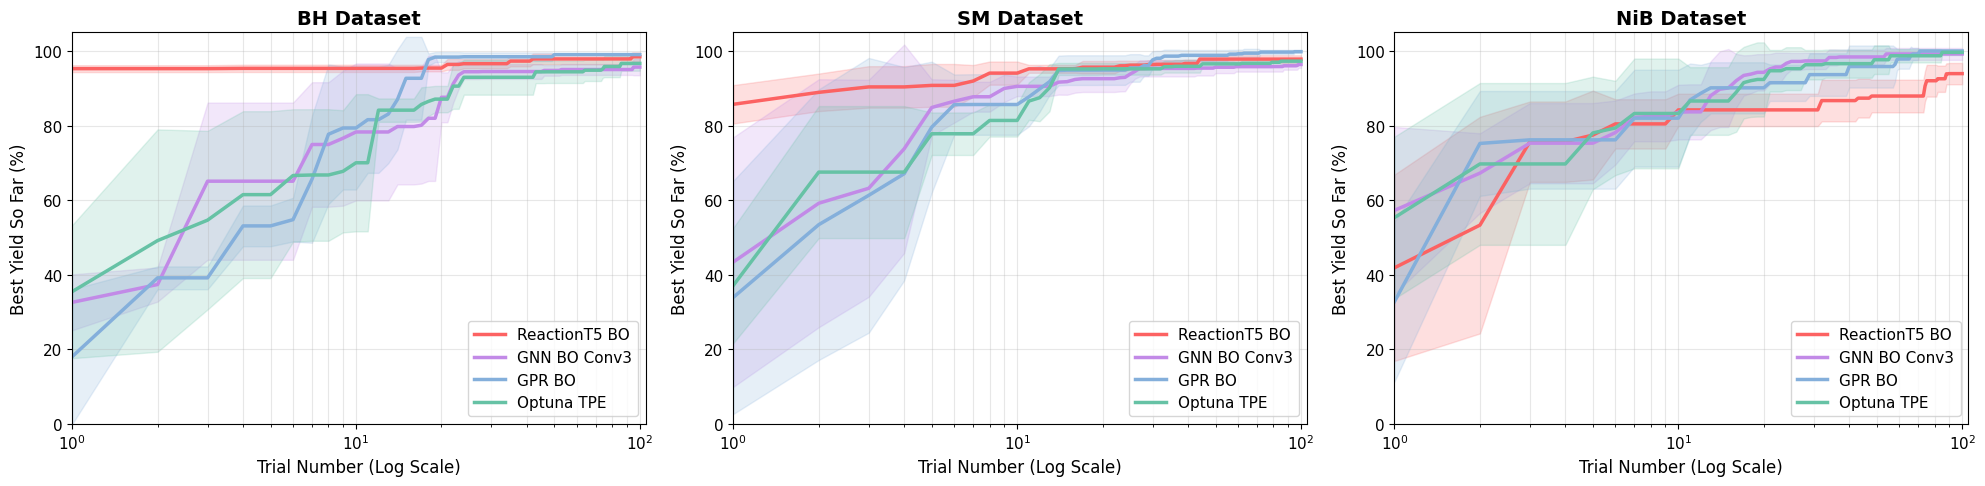

Optimization Progress比較プロット（横軸Log）完了


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors = ["#fc6262", "#c28ae7", "#84afdb", "#66c2a5"]

for i, dataset in enumerate(datasets):
    ax = axes[i]
    
    for j, (model, model_label) in enumerate(zip(target_models, target_labels)):
        all_progress = []
        
        for seed in seeds:
            df_subset = combined_df[
                (combined_df['dataset'] == dataset) & 
                (combined_df['model'] == model) & 
                (combined_df['seed'] == seed)
            ].copy()
            
            if len(df_subset) > 0:
                if 'trial' in df_subset.columns:
                    df_subset = df_subset.sort_values('trial')
                
                # 累積最大値を計算
                cumulative_max = df_subset['actual_yield'].cummax().values
                all_progress.append(cumulative_max)
        
        if all_progress:
            # 長さを揃える（最小の長さに合わせる）
            lengths = [len(p) for p in all_progress]
            min_len = min(lengths)
            all_progress = [p[:min_len] for p in all_progress]
            
            # 平均と標準偏差の計算
            all_progress = np.array(all_progress)
            mean_progress = np.mean(all_progress, axis=0)
            std_progress = np.std(all_progress, axis=0)
            
            # X軸（試行回数）の準備：1から開始
            trials = np.arange(1, len(mean_progress) + 1)
            
            # プロット
            ax.plot(trials, mean_progress, label=f'{model_label}', 
                   linewidth=2.5, color=colors[j])
            ax.fill_between(trials, 
                           mean_progress - std_progress,
                           mean_progress + std_progress,
                           alpha=0.2, color=colors[j])
    
    # 軸とタイトルの設定
    ax.set_title(f'{dataset} Dataset', fontsize=14, fontweight='bold')
    ax.set_xlabel('Trial Number (Log Scale)', fontsize=12)
    ax.set_ylabel('Best Yield So Far (%)', fontsize=12)
    
    # --- 横軸を対数スケールに変更 ---
    ax.set_xscale('log')
    # 0は表示できないため、1から最大試行回数（例: 100）までに設定
    ax.set_xlim([1, 105]) 
    # ------------------------------
    
    # 縦軸の設定
    ax.set_ylim([0, 105])
    
    # グリッドの設定（which="both" で対数軸の補助目盛にも線を引く）
    ax.grid(True, which="both", ls="-", alpha=0.3)
    ax.legend(fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()

print("Optimization Progress比較プロット（横軸Log）完了")

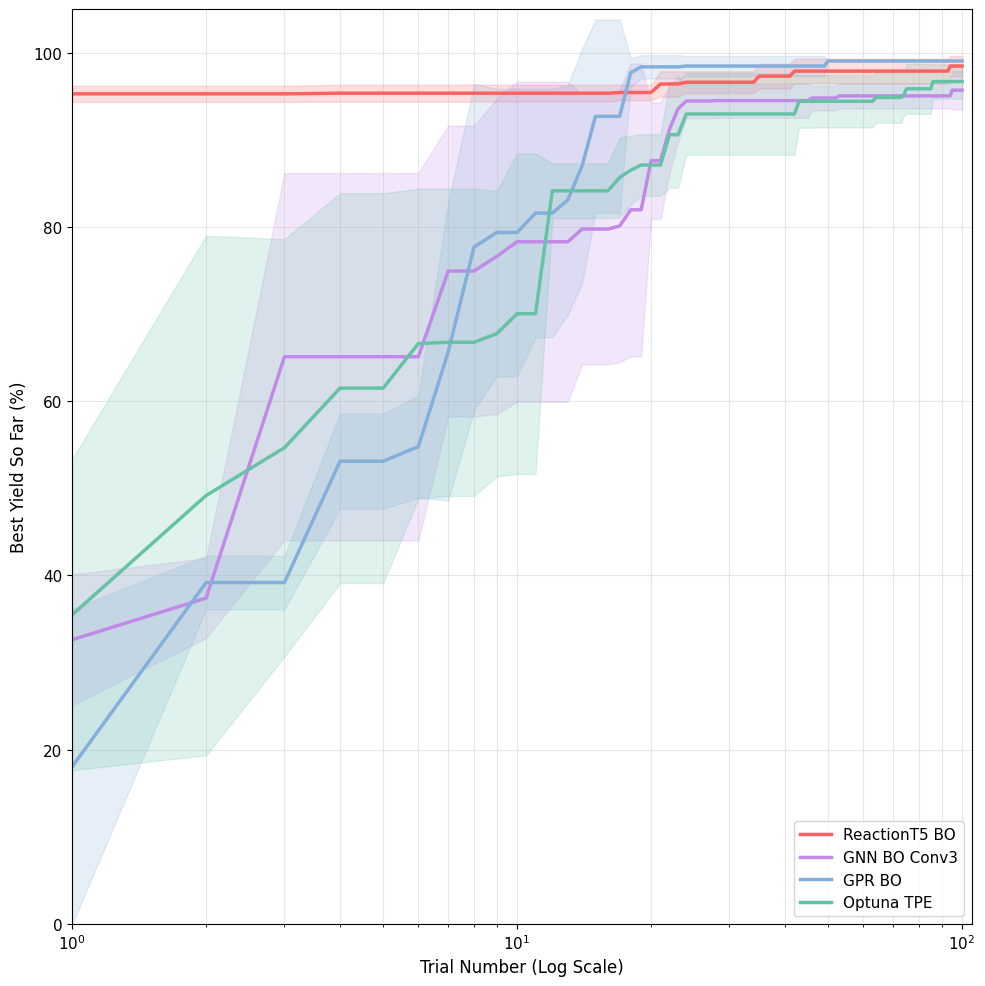

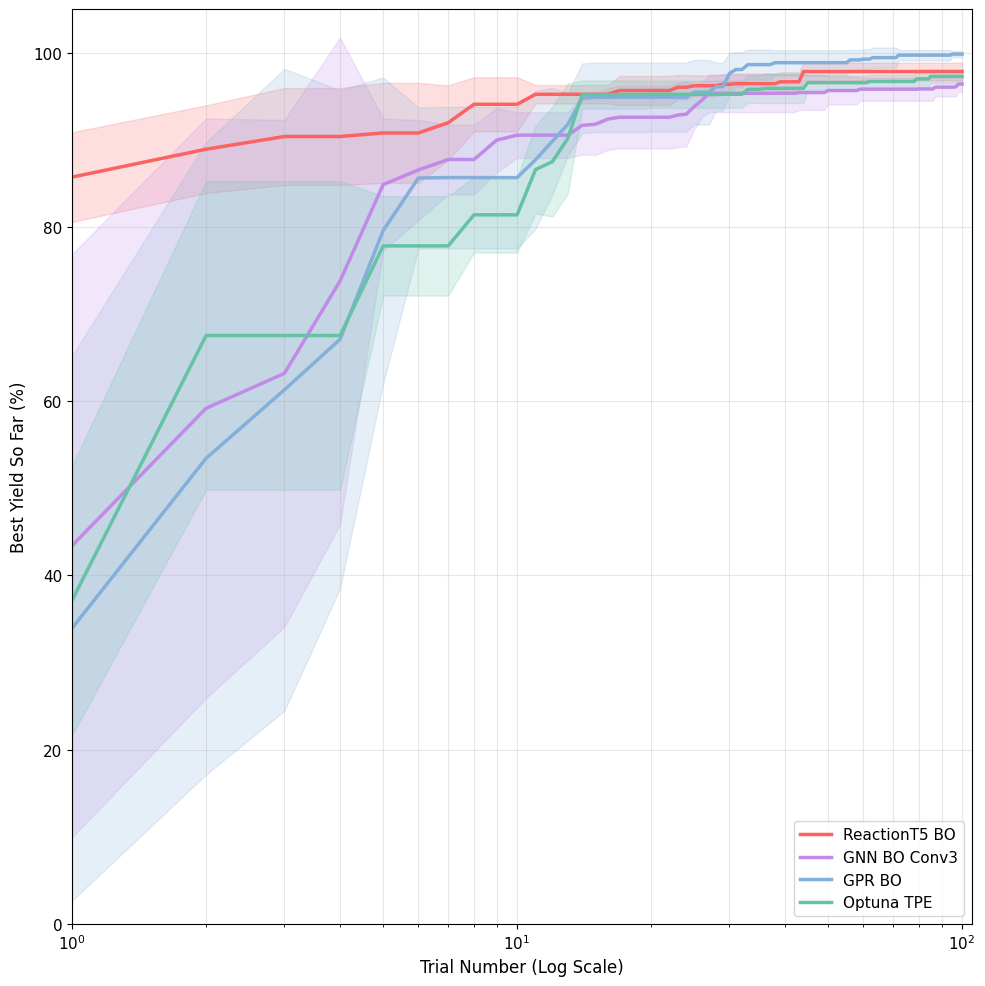

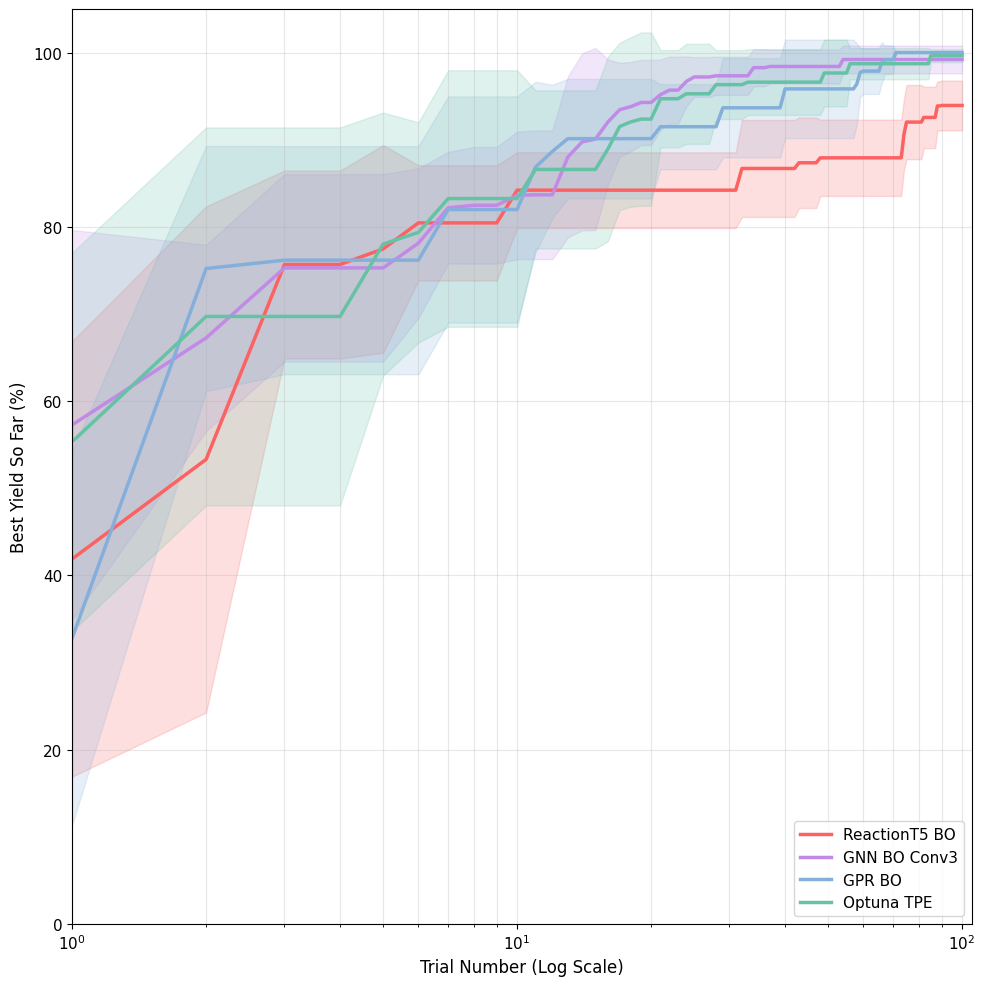

In [18]:
# 3つのデータセットを個別に出力
dataset_display_names = {'NiB': 'NiB', 'SM': 'Suzuki-Miyaura', 'BH': 'Buchwald-Hartwig'}

for i, dataset in enumerate(datasets):
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    for j, (model, model_label) in enumerate(zip(target_models, target_labels)):
        all_progress = []

        for seed in seeds:
            df_subset = combined_df[
                (combined_df['dataset'] == dataset) &
                (combined_df['model'] == model) &
                (combined_df['seed'] == seed)
            ].copy()

            if len(df_subset) > 0:
                if 'trial' in df_subset.columns:
                    df_subset = df_subset.sort_values('trial')
                cumulative_max = df_subset['actual_yield'].cummax().values
                all_progress.append(cumulative_max)

        if all_progress:
            lengths = [len(p) for p in all_progress]
            min_len = min(lengths)
            all_progress = np.array([p[:min_len] for p in all_progress])
            mean_progress = np.mean(all_progress, axis=0)
            std_progress = np.std(all_progress, axis=0)
            trials = np.arange(1, len(mean_progress) + 1)

            ax.plot(trials, mean_progress, label=model_label,
                    linewidth=2.5, color=colors[j])
            ax.fill_between(trials,
                            mean_progress - std_progress,
                            mean_progress + std_progress,
                            alpha=0.2, color=colors[j])

    ax.set_xlabel('Trial Number (Log Scale)', fontsize=12)
    ax.set_ylabel('Best Yield So Far (%)', fontsize=12)
    ax.set_xscale('log')
    ax.set_xlim([1, 105])
    ax.set_ylim([0, 105])
    ax.grid(True, which="both", ls="-", alpha=0.3)
    ax.legend(fontsize=11, loc='lower right')

    plt.tight_layout()
    plt.show()
